# K-means Clustering Algorithm
- unsurpervised learning

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

这里实现K-means聚类的基础功能


In [3]:
data1 = loadmat('data/ex7data1.mat')
data1

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Nov 14 22:41:44 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[3.38156267, 3.38911268],
        [4.52787538, 5.8541781 ],
        [2.65568187, 4.41199472],
        [2.76523467, 3.71541365],
        [2.84656011, 4.17550645],
        [3.89067196, 6.48838087],
        [3.47580524, 3.63284876],
        [5.91129845, 6.68076853],
        [3.92889397, 5.09844661],
        [4.56183537, 5.62329929],
        [4.57407171, 5.39765069],
        [4.37173356, 5.46116549],
        [4.19169388, 4.95469359],
        [5.24408518, 4.66148767],
        [2.8358402 , 3.76801716],
        [5.63526969, 6.31211438],
        [4.68632968, 5.6652411 ],
        [2.85051337, 4.62645627],
        [5.1101573 , 7.36319662],
        [5.18256377, 4.64650909],
        [5.70732809, 6.68103995],
        [3.57968458, 4.80278074],
        [5.63937773, 6.12043594],
        [4.26346851, 4.68942896],
        [2.53651693, 3.88449078],
      

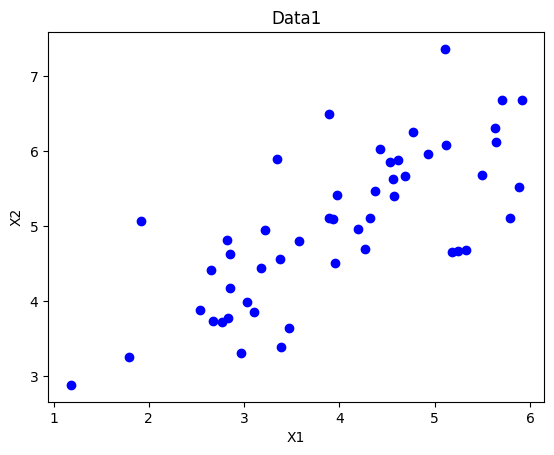

In [4]:
# show data1
X = data1['X']
plt.scatter(X[:,0],X[:,1],marker='o',c='b')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Data1')
plt.show()

In [5]:
data2 = loadmat('data/ex7data2.mat')
data2

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Wed Nov 16 00:48:22 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[ 1.84207953,  4.6075716 ],
        [ 5.65858312,  4.79996405],
        [ 6.35257892,  3.2908545 ],
        [ 2.90401653,  4.61220411],
        [ 3.23197916,  4.93989405],
        [ 1.24792268,  4.93267846],
        [ 1.97619886,  4.43489674],
        [ 2.23454135,  5.05547168],
        [ 2.98340757,  4.84046406],
        [ 2.97970391,  4.80671081],
        [ 2.11496411,  5.37373587],
        [ 2.12169543,  5.20854212],
        [ 1.5143529 ,  4.77003303],
        [ 2.16979227,  5.27435354],
        [ 0.41852373,  4.88312522],
        [ 2.47053695,  4.80418944],
        [ 4.06069132,  4.99503862],
        [ 3.00708934,  4.67897758],
        [ 0.66632346,  4.87187949],
        [ 3.1621865 ,  4.83658301],
        [ 0.51155258,  4.91052923],
        [ 3.1342801 ,  4.96178114],
        [ 2.04974595,  5.6241395 ],
        [ 0.66582785,  5.243

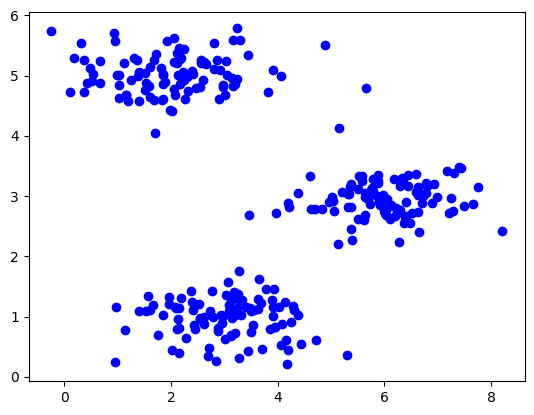

In [6]:
X2 = data2['X']
plt.scatter(X2[:,0],X2[:,1],marker='o',c='b')
plt.show()

In [7]:
# randomly initialize the centroids
def ran_init_centroids(X:np.ndarray,K:int)->np.ndarray:
    m = X.shape[0]
    index = np.random.choice(m,K,replace=False)
    centroids = X[index]
    return centroids

In [8]:
# assign each pint to its closest centroid
def find_closest_centroids(X:np.ndarray,centroids:np.ndarray)->np.ndarray:
    m = X.shape[0]
    K = centroids.shape[0]
    idx = np.zeros(m)
    for i in range(m):
        x_tmp = X[i]
        dist = np.sum((centroids - x_tmp)**2,axis=1) #axis=1表示按行计算
        idx[i] = np.argmin(dist)
    return idx

In [9]:
# move the centroids to the mean of the points assugned to it
def move_centroids(X:np.ndarray,idx:np.ndarray,centroids:np.ndarray)->np.ndarray:
    K = centroids.shape[0]
    for i in range(K):
        X_tmp = X[idx==i]
        if X_tmp.shape[0] == 0:
            continue
        X_mean = np.sum(X_tmp,axis=0)/X_tmp.shape[0]
        # X_mean = np.mean(X_tmp,axis=0)
        centroids[i] = X_mean


In [10]:
"""
ps:
def will_modify_original(arr):
    arr[0] = 100          # 索引赋值
    arr[:] = 200          # 切片赋值
    arr += 1              # 原地操作
    np.add(arr, 1, out=arr) # 使用out参数

def will_not_modify_original(arr):
    arr = arr + 1         # 创建新数组，不修改原始
    arr = arr * 2         # 创建新数组
    arr = np.sum(arr)     # 创建新对象
"""

'\nps:\ndef will_modify_original(arr):\n    arr[0] = 100          # 索引赋值\n    arr[:] = 200          # 切片赋值\n    arr += 1              # 原地操作\n    np.add(arr, 1, out=arr) # 使用out参数\n\ndef will_not_modify_original(arr):\n    arr = arr + 1         # 创建新数组，不修改原始\n    arr = arr * 2         # 创建新数组\n    arr = np.sum(arr)     # 创建新对象\n'

In [11]:
def cost_func(X:np.ndarray,idx:np.ndarray,centroids:np.ndarray)->float:
    m = X.shape[0]
    # fancy indexing
    # IndexError: arrays used as indices must be of integer (or boolean) type
    centroids_assigned = centroids[idx.astype(int)]# 必须使用类型转换
    return np.sum((X-centroids_assigned)**2)/m

In [12]:
def k_means(X:np.ndarray,K:int,max_iters:int=1000,tolerance:float=1e-6)->tuple[np.ndarray,np.ndarray,np.ndarray]: 
    # 第一个返回idx,第二个返回centroids,第三个返回cost_history
    centroids = ran_init_centroids(X,K)
    cost_history = []
    for i in range(max_iters):
        idx = find_closest_centroids(X,centroids)
        cost_history.append(cost_func(X,idx,centroids))
        move_centroids(X,idx,centroids)
        cost_history.append(cost_func(X,idx,centroids))
        if np.abs(cost_history[-1]-cost_history[-2]) < tolerance:
            break
    return idx,centroids,cost_history

- 由于增加centroid数量必然使得cost下降，所以不能通过计算训练好的cost比较大小来选择K，以确定K或者减小cost
- 存在一种方法叫elbow辅助自动选择centroid

In [13]:
def muti_k_means(X:np.ndarray,K:int,n_init:int=10,max_iters:int=1000,tolerance:float=1e-6)->tuple[np.ndarray,np.ndarray,np.ndarray]: 
    best_cost = float('inf')
    best_idx = None
    best_centroids = None
    best_cost_history = None
    for i in range(n_init):
        idx,centroids,cost_history = k_means(X,K,max_iters,tolerance)
        final_cost = cost_history[-1]
        if final_cost < best_cost:
            best_cost = final_cost
            best_idx = idx
            best_centroids = centroids
            best_cost_history = cost_history
    return best_idx,best_centroids,best_cost_history

- 对于data1，这里尝试应用“划分衣服大小码”的问题背景
- 对于data2，这里尝试划分类

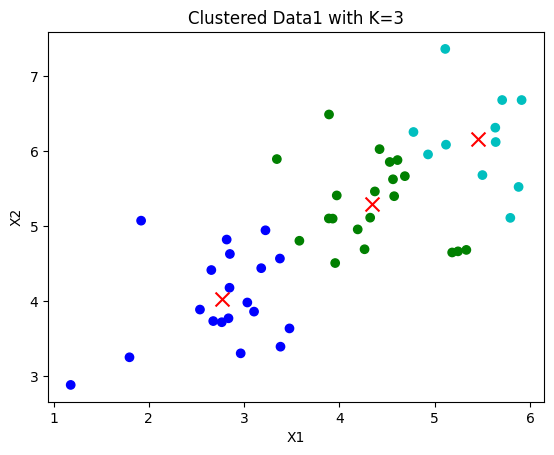

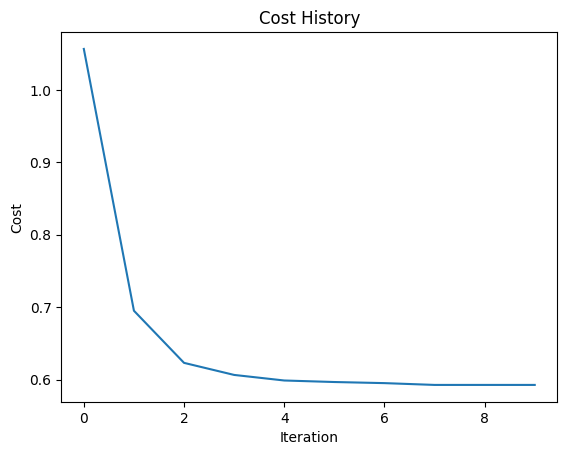

In [14]:
# cluster data1
K=3
idx,centroids,cost_history = muti_k_means(X,K)
# plot the clustered data1
idx_colors = np.zeros(idx.shape)
idx_colors = idx_colors.astype(str)
idx_colors[idx==0] = 'b'
idx_colors[idx==1] = 'g'
idx_colors[idx==2] = 'c' #cyan 青色
plt.scatter(X[:,0],X[:,1],c=idx_colors,marker='o')
plt.scatter(centroids[:,0],centroids[:,1],c='r',marker='x',s=100)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Clustered Data1 with K=3')
plt.show()

# plot the cost history
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost History')
plt.show()

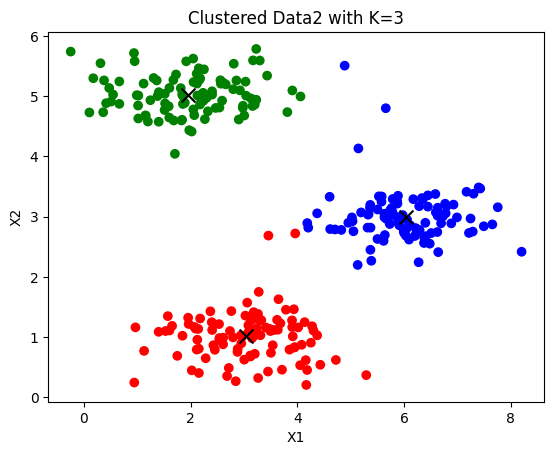

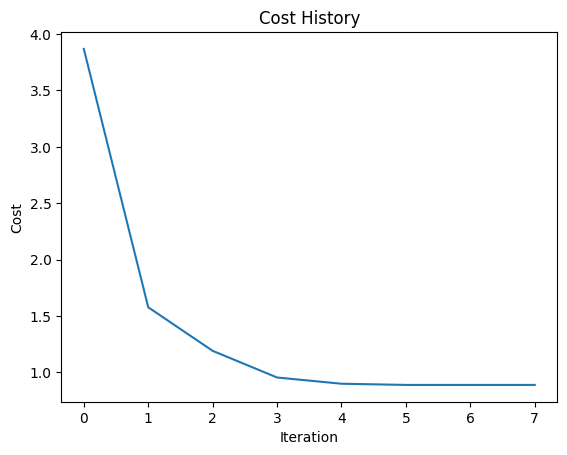

In [15]:
# cluster data2
K = 3
idx,centroids,cost_history = muti_k_means(X2,K)
# plot the clustered data2
idx_colors = np.zeros(idx.shape).astype(str)
idx_colors[idx==0] = 'b'
idx_colors[idx==1] = 'g'
idx_colors[idx==2] = 'r'
plt.scatter(X2[:,0],X2[:,1],c=idx_colors,marker='o')
plt.scatter(centroids[:,0],centroids[:,1],c='black',marker='x',s=100)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Clustered Data2 with K=3')
plt.show()
# plot the cost history
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost History')
plt.show()

### Summary
k-mean聚类算法只能锁定centroid圆半径内的点，有时导致一坨连贯的点会有部分点被分出去

这是K-means算法的一个固有局限性。K-means基于欧氏距离和球形边界的假设，确实会导致连贯的点被不合理地分割。

K-means的局限性,问题原因：
- 球形边界假设：K-means假设每个簇呈球形分布

- 仅考虑距离：只根据到质心的距离分配点

- 硬分配：每个点只能属于一个簇

# THE MOST THRILLING PART!!!

接下来使用K-means实现图片压缩（通过判断最主要图片的颜色来减少颜色实现图片压缩）


data文件夹中提供了图片的二进制格式，可以直接使用

In [16]:
# Load the picture and show it
from PIL import Image
img = Image.open('data/bird_small.png')


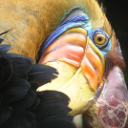

In [17]:
# Or
from IPython.display import Image
Image(filename='data/bird_small.png')

In [18]:
img_data = loadmat('data/bird_small.mat')
img_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Tue Jun  5 04:06:24 2012',
 '__version__': '1.0',
 '__globals__': [],
 'A': array([[[219, 180, 103],
         [230, 185, 116],
         [226, 186, 110],
         ...,
         [ 14,  15,  13],
         [ 13,  15,  12],
         [ 12,  14,  12]],
 
        [[230, 193, 119],
         [224, 192, 120],
         [226, 192, 124],
         ...,
         [ 16,  16,  13],
         [ 14,  15,  10],
         [ 11,  14,   9]],
 
        [[228, 191, 123],
         [228, 191, 121],
         [220, 185, 118],
         ...,
         [ 14,  16,  13],
         [ 13,  13,  11],
         [ 11,  15,  10]],
 
        ...,
 
        [[ 15,  18,  16],
         [ 18,  21,  18],
         [ 18,  19,  16],
         ...,
         [ 81,  45,  45],
         [ 70,  43,  35],
         [ 72,  51,  43]],
 
        [[ 16,  17,  17],
         [ 17,  18,  19],
         [ 20,  19,  20],
         ...,
         [ 80,  38,  40],
         [ 68,  39,  40],
     

In [19]:
X = img_data['A']
X[0,:,:].shape # X[0,:]效果一样但是不好


(128, 3)

In [20]:
# 给数据集的元素添加x,y坐标, 这是一种基于位置的压缩,会修改颜色的位置导致图片失真，不添加坐标的话，可以实现颜色的压缩，减少颜色使用
processed_X = []
m,n,tmp=X.shape #(128, 128, 3)
for i in range(m):
    # 获取当前行的所有像素（n x channels）
    X_line = X[i, :, :]  # 形状: (128, 3)
    
    # 创建x坐标列（所有值为i）
    x_coords = np.full((n, 1), i)  # 形状: (128, 1)
    
    # 创建y坐标列（0到n-1）
    y_coords = np.arange(n).reshape(-1, 1)  # 形状: (128, 1)
    
    # 水平堆叠：颜色通道 + x坐标 + y坐标
    # X_line.T 将 (128, 3) 转为 (3, 128)，然后与其他列堆叠
    X_line_with_coords = np.hstack((X_line, x_coords, y_coords))  # 形状: (128, 5)
    
    processed_X.append(X_line_with_coords)
processed_X = np.vstack(processed_X)
processed_X
# print(f"处理后的数据形状: {final_X.shape}") # (16384, 5)

array([[219, 180, 103,   0,   0],
       [230, 185, 116,   0,   1],
       [226, 186, 110,   0,   2],
       ...,
       [ 65,  43,  39, 127, 125],
       [ 58,  37,  38, 127, 126],
       [ 52,  39,  34, 127, 127]])

In [21]:
# 使用meshgrid创建坐标网格（更高效）
m, n, channels = X.shape

# 创建坐标网格
x_coords, y_coords = np.meshgrid(np.arange(m), np.arange(n), indexing='ij')
x_coords = x_coords.reshape(-1, 1)  # 展平为列向量
y_coords = y_coords.reshape(-1, 1)  # 展平为列向量

# 展平颜色数据
color_data = X.reshape(-1, channels)  # (16384, 3)

# 合并所有数据
final_X = np.hstack((color_data, x_coords, y_coords))  # (16384, 5)
final_X
# print(f"处理后的数据形状: {final_X.shape}")

array([[219, 180, 103,   0,   0],
       [230, 185, 116,   0,   1],
       [226, 186, 110,   0,   2],
       ...,
       [ 65,  43,  39, 127, 125],
       [ 58,  37,  38, 127, 126],
       [ 52,  39,  34, 127, 127]])

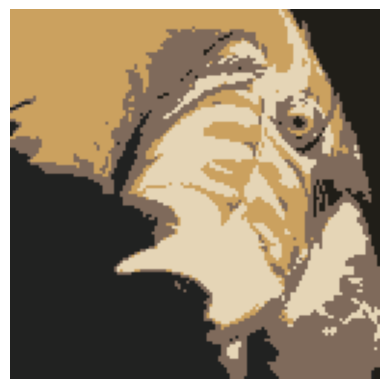

In [ ]:
factor = 56 
K = int((128/factor)**2)
idx,centroids,cost_history = muti_k_means(final_X,K,n_init=10) # 1m54.8s

# process the output data X
X_compressed = centroids[idx.astype(int), :3]  # 只取颜色通道
X_compressed.reshape(m, n, channels)

# diaplay the compressed image
plt.imshow(X_compressed.reshape(128, 128, 3).astype(np.uint8))
plt.axis('off')  # 不显示坐标轴
plt.show()


data文件夹中提供了图片的二进制格式，可以直接使用


|factor | n_init |  times  |                        output                      |
|:-----:|:------:|:-------:|:--------------------------------------------------:|
|  3    |10      | 11m6.4s; 7m53.7s |<img src="img/1.png" alt="drawing" width="250"/>|
| 4|10|3m2.3s|<img src="img/2.png" alt="drawing" width="250"/>|
|8|10|1m15.9s|<img src="img/3.png" alt="drawing" width="250"/>|
|12|10|50.9s|<img src="img/4.png" alt="drawing" width="250"/>|
|16|10|40.3s|<img src="img/5.png" alt="drawing" width="250"/>|
|20|10|35.4s|<img src="img/6.png" alt="drawing" width="250"/>|
|24|10|25.8s|<img src="img/7.png" alt="drawing" width="250"/>|
|28|10|35.8s|<img src="img/8.png" alt="drawing" width="250"/>|
|32|10|23.7s|<img src="img/9.png" alt="drawing" width="250"/>|
|36|10|25.5s|<img src="img/10.png" alt="drawing" width="250"/>|
|40|10|25.2s|<img src="img/11.png" alt="drawing" width="250"/>|
|44|10|13.3s|<img src="img/12.png" alt="drawing" width="250"/>|
|48|10|13.5s|<img src="img/13.png" alt="drawing" width="250"/>|
|52|10|19.9s|<img src="img/14.png" alt="drawing" width="250"/>|
|56|10|12.3|<img src="img/15.png" alt="drawing" width="250"/>|







(16384, 5)

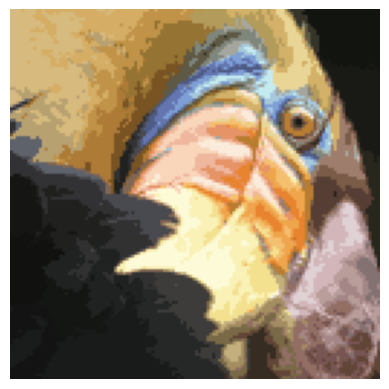

In [50]:
# 应用正则化normalized

factor = 16
K = int((128/factor)**2)

X_normalize = np.hstack((final_X[:,:3] / 255.0 , final_X[:,3:]/128))

idx_2,centroids_2,cost_history_2 = muti_k_means(final_X,K,n_init=3)#15.8s,19.4s，23.5s 21.0s(normalized)

# process the output data X
X_compressed_2 = centroids_2[idx_2.astype(int), :3]  # 只取颜色通道

X_compressed_2 = np.abs(X_compressed_2-255) * 255.0 # 不使用np.abs(X_compressed_2-255)颜色竟然是反转的
X_compressed_2 = X_compressed_2.reshape(128, 128, 3)

# diaplay the compressed image
plt.imshow(X_compressed_2.astype(np.uint8))
plt.axis('off')  # 不显示坐标轴
plt.show()

In [52]:
# 保留元素位置信息直接压缩
X_img = img_data['A']

X_img = X_img.reshape(-1,3)# reshape通过return返回修改后对象，不能直接修改类对象本体
X_img.shape
X_img_normalized = X_img / 255

### 直接压缩颜色通道,X的维度数显著减少，时间反而增加了，猜测x，y位置限制了centroid的扩张

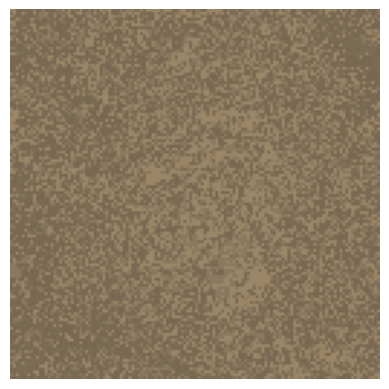

In [53]:
# unnormalized
factor = 64
K = int((128/factor)**2)

idx_changecolor,centroids_changecolor,tmp = muti_k_means(X_img,K,n_init=5,tolerance = 1e-3)# 使用未normalized的数据训练时间大幅度提升
X_compressed_changecolor = centroids_changecolor[idx_changecolor.astype(int)]

X_compressed_changecolor = X_compressed_changecolor.reshape(m,n,3)
plt.imshow(X_compressed_changecolor.astype(np.uint8))
plt.axis('off')
plt.show()

逆天程度无法言语形容（有图有真相）(ps:rolerance=1e-3是后加的，原来没有)
![屏幕截图 2025-09-21 001111.png](<attachment:屏幕截图 2025-09-21 001111.png>)
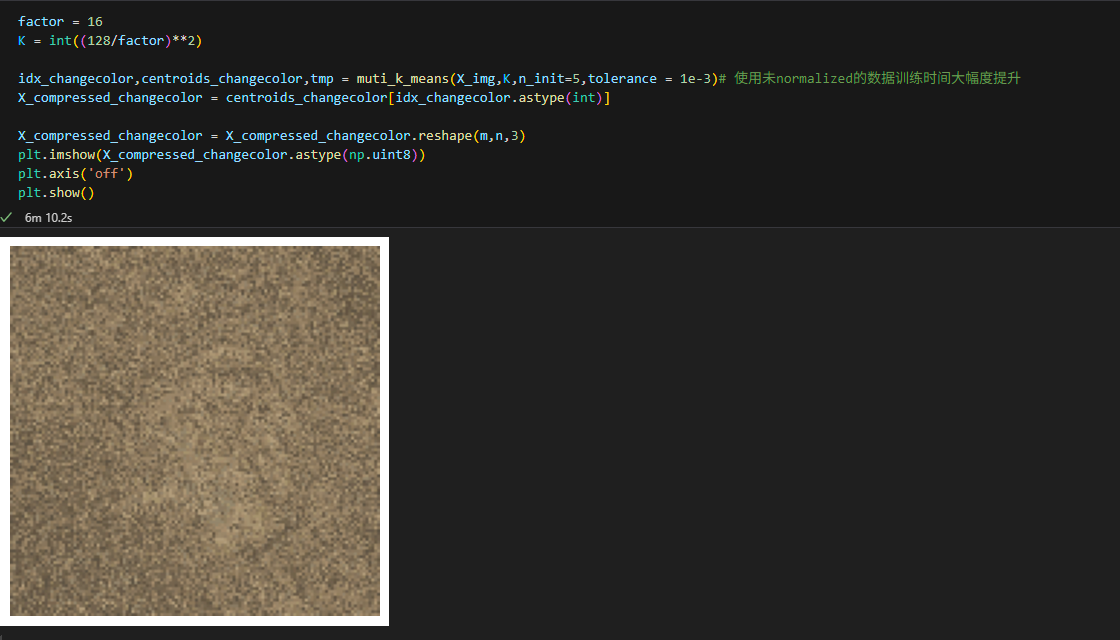

**产生这个问题原因看note.ipynb**

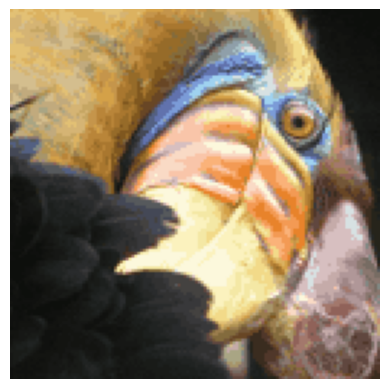

In [ ]:
# 正则化之后变好了
factor = 16
K = int((128/factor)**2)

idx_changecolor,centroids_changecolor,tmp = muti_k_means(X_img_normalized,K,n_init=5)# 11.6s
X_compressed_changecolor = centroids_changecolor[idx_changecolor.astype(int)]

X_compressed_changecolor = X_compressed_changecolor * 256

X_compressed_changecolor = X_compressed_changecolor.reshape(m,n,3)
plt.imshow(X_compressed_changecolor.astype(np.uint8))
plt.axis('off')
plt.show()